# Oscillatory game at $\omega=4\pi$: DTB with periodic neural-network refitting

This notebook changes the parameter update used after the DTB velocity projection. Ordinary outer steps draw a random tangent-coordinate subset $S_k$. At scheduled refit steps, $S_k$ contains every trainable MMNN coordinate, so the particle update uses the full parameter tangent. Each step computes

$$
\alpha_k=\arg\min_\alpha
\left\|J_{S_k}(\theta_k,z)\alpha-b(X_k)\right\|_2^2.
$$

The physical particles retain the same projected Euler update:

$$
X_{k+1}=X_k+hJ_{S_k}(\theta_k,z)\alpha_k.
$$

At scheduled refit times, instead of setting $\theta_{k+1}[S_k]=\theta_k[S_k]+h\alpha_k$, all trainable MMNN parameters are warm-started from $\theta_k$ and refitted to the new state:

$$
\theta_{k+1}
=
\arg\min_\theta
\frac{1}{N}\left\|T_\theta(z)-X_{k+1}\right\|_F^2.
$$

There is **no parameter penalty** in this objective. Between refit events, $\theta$ stays fixed. The fitted network does not overwrite $X_{k+1}$; it supplies the adaptive tangent basis for subsequent outer steps. A refined RK4 trajectory evolves the same initial particles for comparison.

In [ ]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import torch

# Locate this project for numerical output.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'pyproject.toml').is_file() and (path / 'src' / 'dtb_game').is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError('Open this notebook from the project checkout.')

from dtb_game import (NetworkRefitConfig, OscillatoryNonpotentialGame, RefitDTBConfig, ResidualMMNN, run_refit_dtb)
from dtb_game.models import (count_parameters)
from dtb_game.utils import (resolve_device, resolve_dtype, warmup_cuda, write_csv)

output_dir = repo_root / 'results' / 'oscillatory_4pi_refit_dtb'
output_dir.mkdir(parents=True, exist_ok=True)
print('repository:', repo_root)
print('output:', output_dir)


## 1. Experiment controls

The outer method uses fixed initial labels and a residual MMNN. Ordinary steps use a newly sampled tangent subset; scheduled refit steps use the full tangent basis. The inner Adam fit updates **all** trainable MMNN parameters. Set `REFIT_INTERVAL_FRACTION` to the desired proportion of the complete outer time grid. A value of `0.10` means one refit every 10% of the outer steps. `REFIT_RELATIVE_TOLERANCE` compares the final network-particle RMS with the accumulated particle displacement since the previous refit.

In [2]:
SEED = 2026
MODEL_SEED = SEED + 100
KAPPA = 1.0
AMPLITUDE = 1.0
OMEGA = 4.0 * np.pi

# Outer projected DTB trajectory and refined RK4 reference.
N_PARTICLES = 2000
STEP_SIZE = 0.002
FINAL_TIME = 0.2
SNAPSHOT_TIMES = (0.0, 0.05, 0.1, 0.2)
RK4_REFERENCE_STEP = 0.00025

# Residual MMNN and random tangent-coordinate subset.
MMNN_WIDTH = 12
MMNN_RANK = 12
MMNN_DEPTH = 3
ACTIVATION = 'tanh'
TANGENT_SUBSET_SIZE = None
SVD_RTOL = 1e-4
JACOBIAN_CHUNK = 512

# Pure supervised refit: no parameter penalty is used.
REFIT_LEARNING_RATE = 1e-3
REFIT_MAXIMUM_STEPS = 100
REFIT_RELATIVE_TOLERANCE = 0.05
REFIT_ABSOLUTE_TOLERANCE = 1e-7

# With 100 outer steps, 0.10 schedules a refit every 10 steps.
REFIT_INTERVAL_FRACTION = 0.10

DEVICE_NAME = 'auto'
DTYPE_NAME = 'float64'
DEVICE = resolve_device(DEVICE_NAME)
DTYPE = resolve_dtype(DTYPE_NAME)
warmup_cuda(DEVICE, DTYPE)

print({
    'device': str(DEVICE),
    'dtype': str(DTYPE),
    'omega': OMEGA,
    'particles': N_PARTICLES,
    'outer_steps': int(round(FINAL_TIME / STEP_SIZE)),
    'tangent_subset_size': TANGENT_SUBSET_SIZE,
    'refit_maximum_steps': REFIT_MAXIMUM_STEPS,
    'refit_relative_tolerance': REFIT_RELATIVE_TOLERANCE,
    'refit_interval_fraction': REFIT_INTERVAL_FRACTION,
})


{'device': 'cuda', 'dtype': 'torch.float64', 'omega': 12.566370614359172, 'particles': 2000, 'outer_steps': 100, 'tangent_subset_size': None, 'refit_maximum_steps': 100, 'refit_relative_tolerance': 0.05, 'refit_interval_fraction': 0.1}


## 2. Run the refit-based DTB method

`run_refit_dtb` reuses the package tangent Jacobian, truncated-SVD projection, sampling, time-grid, and RK4 functions. Ordinary steps use the configured random subset, while scheduled refit steps use the full parameter tangent. The returned particle trajectory always follows

$$
X_{k+1}=X_k+hJ_{S_k}\alpha_k,
$$

while the refit only changes the tangent basis used after that event. The final outer step is always treated as a refit event, even when the requested interval does not divide the total step count.

In [ ]:
torch.manual_seed(MODEL_SEED)
model = ResidualMMNN(
    2,
    width=MMNN_WIDTH,
    rank=MMNN_RANK,
    depth=MMNN_DEPTH,
    activation=ACTIVATION,
    dtype=DTYPE,
    zero_init_output=True,
).to(DEVICE)
parameter_count = count_parameters(model)
game = OscillatoryNonpotentialGame(KAPPA, AMPLITUDE, float(OMEGA))

refit_config = NetworkRefitConfig(
    learning_rate=REFIT_LEARNING_RATE,
    maximum_steps=REFIT_MAXIMUM_STEPS,
    relative_tolerance=REFIT_RELATIVE_TOLERANCE,
    absolute_tolerance=REFIT_ABSOLUTE_TOLERANCE,
)
config = RefitDTBConfig(
    particle_count=N_PARTICLES,
    initial_low=-1.0,
    initial_high=1.0,
    step_size=STEP_SIZE,
    final_time=FINAL_TIME,
    snapshot_times=SNAPSHOT_TIMES,
    basis_size= parameter_count,
    svd_rtol=SVD_RTOL,
    jacobian_chunk=JACOBIAN_CHUNK,
    reference_step_size=RK4_REFERENCE_STEP,
    seed=SEED,
    dtype=DTYPE_NAME,
    device=DEVICE_NAME,
    progress_reports=5,
    refit_interval_fraction=REFIT_INTERVAL_FRACTION,
    refit=refit_config,
)

result = run_refit_dtb(game, model, config)
print({
    'trainable_coordinates': parameter_count,
    'random_tangent_subset_size': config.basis_size,
    'full_refit_tangent_size': parameter_count,
    'outer_steps_between_refits': result.refit_stride,
    'refit_event_count': len(result.refit_times),
    'outer_steps': len(result.projection_times),
    'refit_convergence_fraction': float(result.refit_converged.mean()),
    'final_refit_RMS': float(result.refit_rms_after[-1]),
    'final_relative_projection_error_at_T': result.final_relative_projection_error,
    'final_alpha_norm_at_T': result.final_alpha_norm,
    'final_DTB_RK4_RMS': result.final_paired_rms,
})


## 3. Matched particle-cloud snapshots

The upper row shows the projected DTB particles. The lower row shows the refined RK4 reference initialized with exactly the same labeled particles. All panels share common limits.

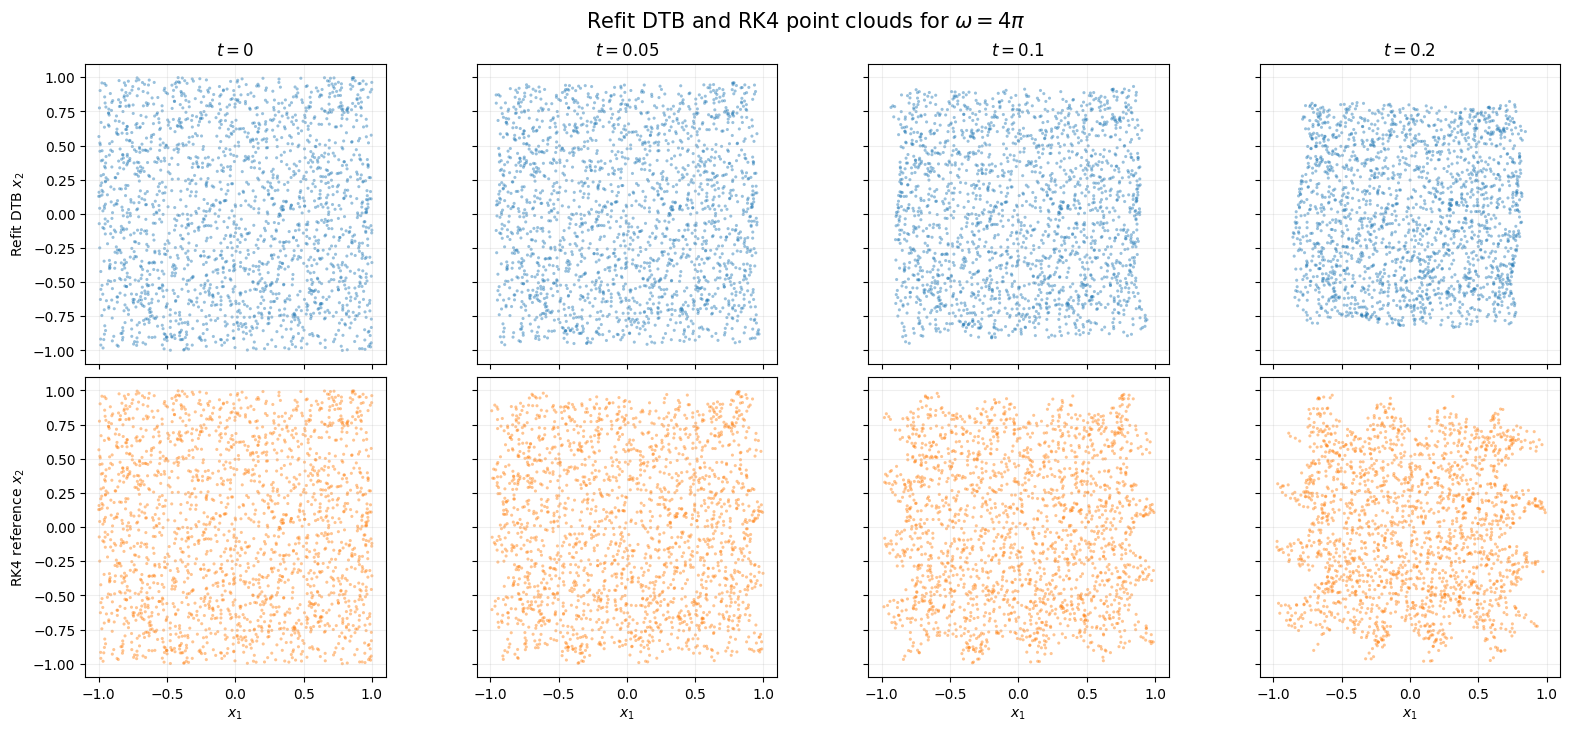

saved: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/oscillatory_4pi_refit_dtb/refit_dtb_rk4_point_cloud_snapshots.png


In [4]:
snapshot_times = sorted(result.dtb_snapshots)
plot_count = min(N_PARTICLES, 3000)
plot_indices = np.arange(plot_count)

all_clouds = []
for snapshot_time in snapshot_times:
    all_clouds.extend([
        result.dtb_snapshots[snapshot_time],
        result.reference_snapshots[snapshot_time],
    ])
all_points = np.concatenate(all_clouds, axis=0)
x_min, y_min = all_points.min(axis=0)
x_max, y_max = all_points.max(axis=0)
x_padding = max(0.05 * (x_max - x_min), 0.02)
y_padding = max(0.05 * (y_max - y_min), 0.02)

fig, axes = plt.subplots(
    2, len(snapshot_times), figsize=(4.0 * len(snapshot_times), 7.2),
    sharex=True, sharey=True, constrained_layout=True,
)
for column, snapshot_time in enumerate(snapshot_times):
    dtb_cloud = result.dtb_snapshots[snapshot_time][plot_indices]
    reference_cloud = result.reference_snapshots[snapshot_time][plot_indices]
    axes[0, column].scatter(
        dtb_cloud[:, 0], dtb_cloud[:, 1], s=5, alpha=0.45,
        color='tab:blue', edgecolors='none',
    )
    axes[1, column].scatter(
        reference_cloud[:, 0], reference_cloud[:, 1], s=5, alpha=0.45,
        color='tab:orange', edgecolors='none',
    )
    axes[0, column].set_title(fr'$t={snapshot_time:g}$')
    axes[1, column].set_xlabel(r'$x_1$')
    for row in range(2):
        axes[row, column].set_xlim(x_min - x_padding, x_max + x_padding)
        axes[row, column].set_ylim(y_min - y_padding, y_max + y_padding)
        axes[row, column].set_aspect('equal', adjustable='box')
        axes[row, column].grid(True, alpha=0.2)
axes[0, 0].set_ylabel(r'Refit DTB $x_2$')
axes[1, 0].set_ylabel(r'RK4 reference $x_2$')
fig.suptitle(r'Refit DTB and RK4 point clouds for $\omega=4\pi$', fontsize=15)
snapshot_path = output_dir / 'refit_dtb_rk4_point_cloud_snapshots.png'
fig.savefig(snapshot_path, dpi=180, bbox_inches='tight')
plt.show()
print('saved:', snapshot_path)


## 4. Projection, refit, and trajectory diagnostics

The projection diagnostics are evaluated before each particle update, with one additional full-basis projection at the final state $T$. Refit diagnostics are recorded only at scheduled refit events:

$$
E_{\mathrm{fit},k}
=
\left(\frac{1}{N}\sum_{i=1}^N
\left\|T_{\theta_{k+1}}(z_i)-X_{i,k+1}\right\|_2^2\right)^{1/2}.
$$

The refit does not alter the physical particles. Therefore the DTB/RK4 error measures the projected particle dynamics, while $E_{\mathrm{fit},k}$ measures how accurately the new MMNN basis represents that state.

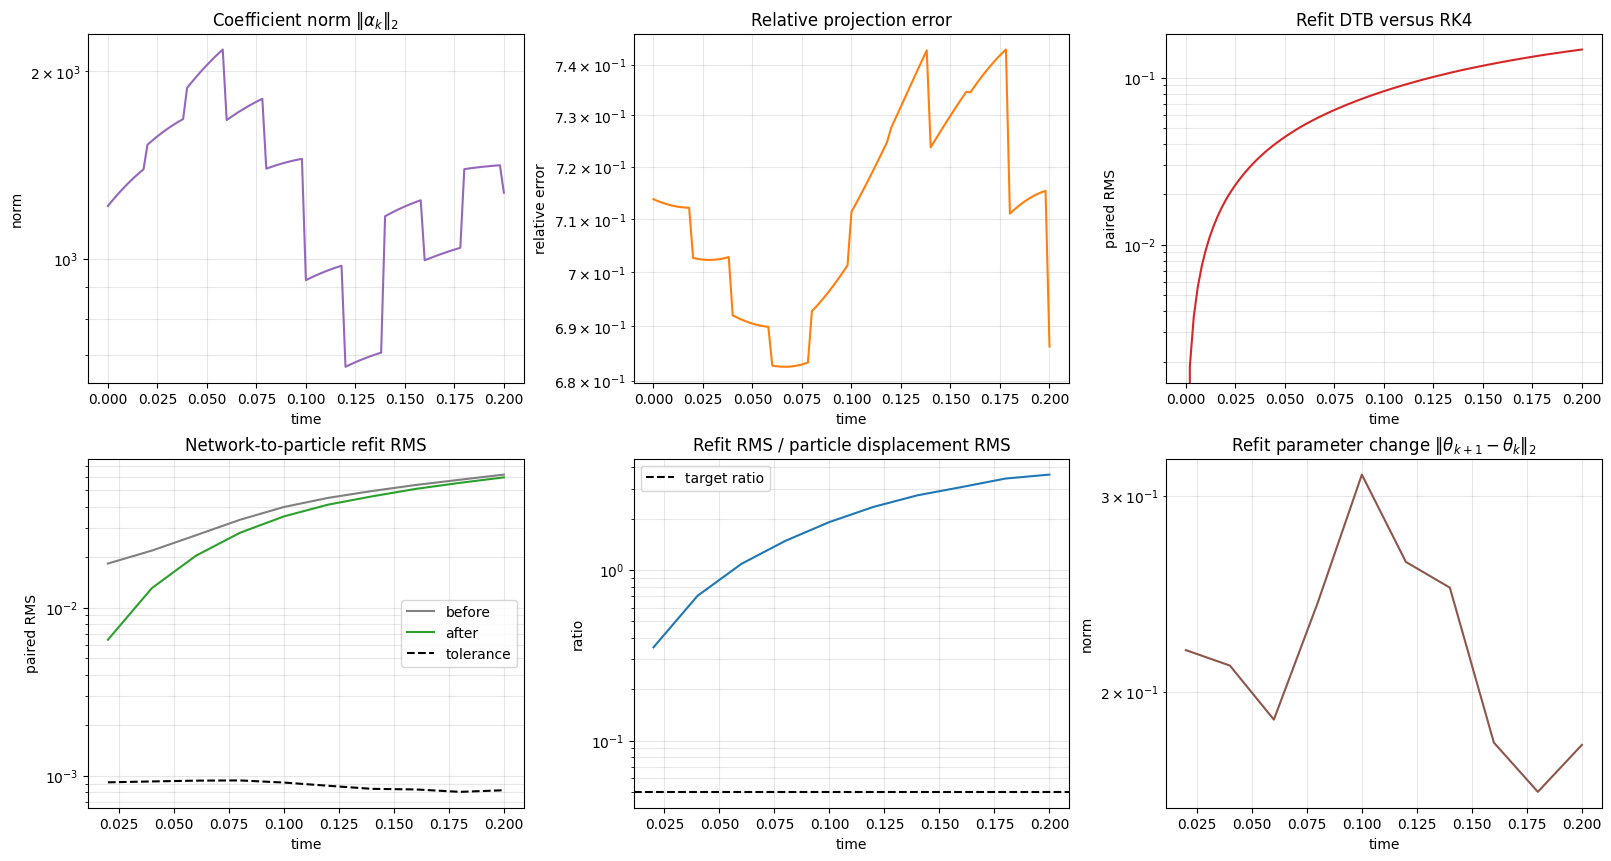

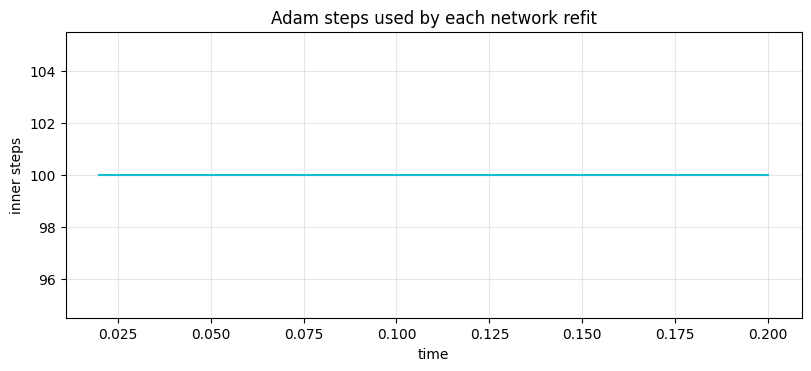

saved: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/oscillatory_4pi_refit_dtb/projection_diagnostics.csv
saved: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/oscillatory_4pi_refit_dtb/refit_diagnostics.csv
saved: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/oscillatory_4pi_refit_dtb/refit_dtb_diagnostics.png
saved: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/oscillatory_4pi_refit_dtb/refit_optimizer_steps.png


In [5]:
# Include a fresh tangent projection at the true final state T.
projection_times = np.append(result.projection_times, result.times[-1])
projection_rms = np.append(result.projection_error, result.final_projection_error)
projection_basis_size = np.append(
    result.projection_basis_size,
    len(result.final_selected_indices),
)
relative_projection = np.append(
    result.relative_projection_error,
    result.final_relative_projection_error,
)
alpha_norm = np.append(result.alpha_norm, result.final_alpha_norm)

projection_csv = write_csv(
    output_dir / 'projection_diagnostics.csv',
    (
        'time', 'rms_projection_error', 'relative_projection_error',
        'alpha_norm', 'tangent_basis_size',
    ),
    zip(
        projection_times, projection_rms, relative_projection, alpha_norm,
        projection_basis_size,
    ),
)
refit_state_indices = np.searchsorted(result.times, result.refit_times)
refit_trajectory_rms = result.trajectory_rms_error[refit_state_indices]
refit_csv = write_csv(
    output_dir / 'refit_diagnostics.csv',
    (
        'time', 'rms_before', 'rms_after', 'relative_rms_after',
        'stopping_tolerance', 'optimizer_steps', 'parameter_change_norm',
        'converged', 'dtb_rk4_rms',
    ),
    zip(
        result.refit_times,
        result.refit_rms_before,
        result.refit_rms_after,
        result.relative_refit_error,
        result.refit_tolerance,
        result.refit_optimizer_steps,
        result.parameter_change_norm,
        result.refit_converged.astype(int),
        refit_trajectory_rms,
    ),
)
np.savez_compressed(
    output_dir / 'refit_dtb_histories.npz',
    times=result.times,
    projection_times=projection_times,
    projection_rms=projection_rms,
    relative_projection=relative_projection,
    alpha_norm=alpha_norm,
    projection_basis_size=projection_basis_size,
    refit_times=result.refit_times,
    refit_rms_before=result.refit_rms_before,
    refit_rms_after=result.refit_rms_after,
    relative_refit_error=result.relative_refit_error,
    refit_optimizer_steps=result.refit_optimizer_steps,
    parameter_change_norm=result.parameter_change_norm,
    trajectory_rms_error=result.trajectory_rms_error,
    final_particles=result.final_particles,
    reference_final_particles=result.reference_final_particles,
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), constrained_layout=True)
axes[0, 0].semilogy(projection_times, alpha_norm, color='tab:purple')
axes[0, 0].set(title=r'Coefficient norm $\|\alpha_k\|_2$', xlabel='time', ylabel='norm')
axes[0, 1].semilogy(projection_times, relative_projection, color='tab:orange')
axes[0, 1].set(title='Relative projection error', xlabel='time', ylabel='relative error')
axes[0, 2].semilogy(result.times, result.trajectory_rms_error, color='tab:red')
axes[0, 2].set(title='Refit DTB versus RK4', xlabel='time', ylabel='paired RMS')

axes[1, 0].semilogy(result.refit_times, result.refit_rms_before, label='before', color='0.5')
axes[1, 0].semilogy(result.refit_times, result.refit_rms_after, label='after', color='tab:green')
axes[1, 0].semilogy(result.refit_times, result.refit_tolerance, '--', label='tolerance', color='black')
axes[1, 0].set(title='Network-to-particle refit RMS', xlabel='time', ylabel='paired RMS')
axes[1, 0].legend()
axes[1, 1].semilogy(result.refit_times, result.relative_refit_error, color='tab:blue')
axes[1, 1].axhline(REFIT_RELATIVE_TOLERANCE, linestyle='--', color='black', label='target ratio')
axes[1, 1].set(title='Refit RMS / particle displacement RMS', xlabel='time', ylabel='ratio')
axes[1, 1].legend()
axes[1, 2].semilogy(result.refit_times, result.parameter_change_norm, color='tab:brown')
axes[1, 2].set(title=r'Refit parameter change $\|\theta_{k+1}-\theta_k\|_2$', xlabel='time', ylabel='norm')
for axis in axes.flat:
    axis.grid(True, which='both', alpha=0.3)
diagnostic_path = output_dir / 'refit_dtb_diagnostics.png'
fig.savefig(diagnostic_path, dpi=180, bbox_inches='tight')
plt.show()

fig, axis = plt.subplots(figsize=(8, 3.6), constrained_layout=True)
axis.plot(result.refit_times, result.refit_optimizer_steps, color='tab:cyan')
axis.set(title='Adam steps used by each network refit', xlabel='time', ylabel='inner steps')
axis.grid(True, alpha=0.3)
optimizer_path = output_dir / 'refit_optimizer_steps.png'
fig.savefig(optimizer_path, dpi=180, bbox_inches='tight')
plt.show()

print('saved:', projection_csv)
print('saved:', refit_csv)
print('saved:', diagnostic_path)
print('saved:', optimizer_path)


## 5. How to interpret the run

- On ordinary steps, a small projection error means the random tangent subset can approximate the game velocity. On refit steps, it measures the best projection obtained from the full parameter tangent.
- A small post-refit RMS means the full MMNN can represent the particle map accumulated since the previous refit using the fixed labels.
- If the post-refit RMS remains above its tolerance, increase `REFIT_MAXIMUM_STEPS`, reduce `REFIT_LEARNING_RATE` if the loss oscillates, or enlarge the MMNN.
- A small refit RMS together with a growing DTB/RK4 error points to tangent projection or outer time-discretization error rather than failure of the supervised fit.
- The parameter-change norm is a diagnostic only. It is not a penalty and does not appear in the refit objective.

In [ ]:
archive_path = Path(shutil.make_archive(
    str(output_dir),
    'zip',
    root_dir=output_dir,
))
print('result archive:', archive_path)
